# 1.2 The Statistical Interpretation

## 1. Born's Rule and Probability Density

In quantum mechanics, a particle's state is fully described by its wave function, $\Psi(x,t)$. However, the wave function itself is a complex quantity and does not directly correspond to a physical observable. Max Born proposed the **statistical interpretation**, stating that the probability of finding the particle in a specific region is determined by the square of the magnitude of its wave function.

The probability $P$ of finding the particle between points $a$ and $b$ at time $t$ is given by:

$$
P_{ab}(t) = \int_{a}^{b} |\Psi(x,t)|^2 dx
$$

Therefore, the probability density is defined as $\rho(x,t) = |\Psi(x,t)|^2$. This interpretation implies that quantum mechanics provides purely statistical information about possible outcomes prior to a measurement.

## 2. Numerical Simulation: Probability Density

To visualize this concept, we can model a one-dimensional normalized Gaussian wave packet and compare the amplitude of the wave function with its corresponding probability density.

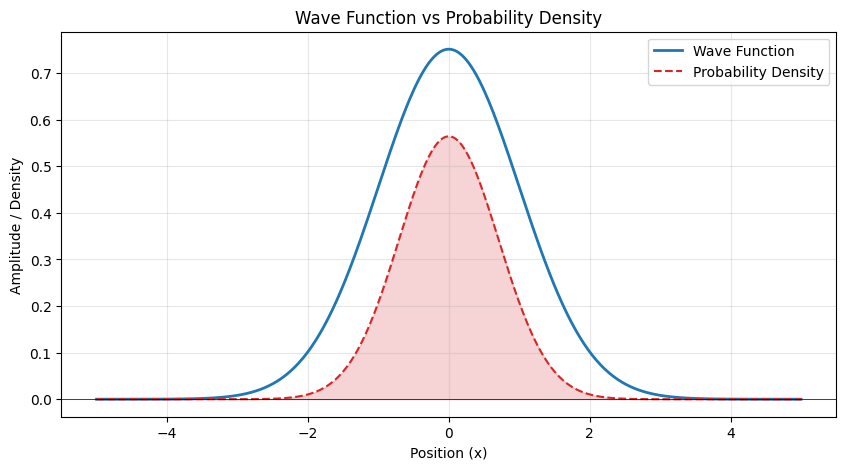

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 500)
# The wave function can be complex, but we use a real Gaussian for simplicity.
sigma = 1.0
psi = (1 / (np.pi * sigma**2)**0.25) * np.exp(-x**2 / (2 * sigma**2))
prob_density = np.abs(psi)**2

plt.figure(figsize=(10, 5))
plt.plot(x, psi, label='Wave Function', color='#1f77b4', linewidth=2)
plt.plot(x, prob_density, label='Probability Density', color='#d62728', linestyle='--')
plt.fill_between(x, prob_density, alpha=0.2, color='#d62728')

plt.title("Wave Function vs Probability Density")
plt.xlabel("Position (x)")
plt.ylabel("Amplitude / Density")
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. The Measurement Process and Wave Function Collapse

According to the orthodox interpretation, a particle does not possess a precise position before a measurement is made. It is the act of measuring that forces the wave function to manifest at a single point.

If a measurement locates the particle precisely at point $C$, the wave function undergoes a sudden and discontinuous change. It transitions from a spread-out probability wave into an infinitely sharp spike centered at $C$. This is known as **wave function collapse**, and the new state is approximated by a Dirac delta function:

$$
\Psi_{\text{measured}}(x) \approx \delta(x - C)
$$

This highlights a fundamental postulate regarding the two distinct ways a quantum system evolves:
1. **Continuous Evolution:** Between measurements, $\Psi$ evolves smoothly and deterministically according to the Schrödinger equation.
2. **Discontinuous Jump:** Upon measurement, the wave function collapses instantaneously based on the statistical probabilities governed by Born's rule.

## 4. Simulating the Quantum Collapse

Numerically, we can simulate this measurement process by treating the probability density array as statistical weights. We randomly draw a position from our spatial grid based on these weights, and then collapse the array into a single point to represent the post-measurement state.

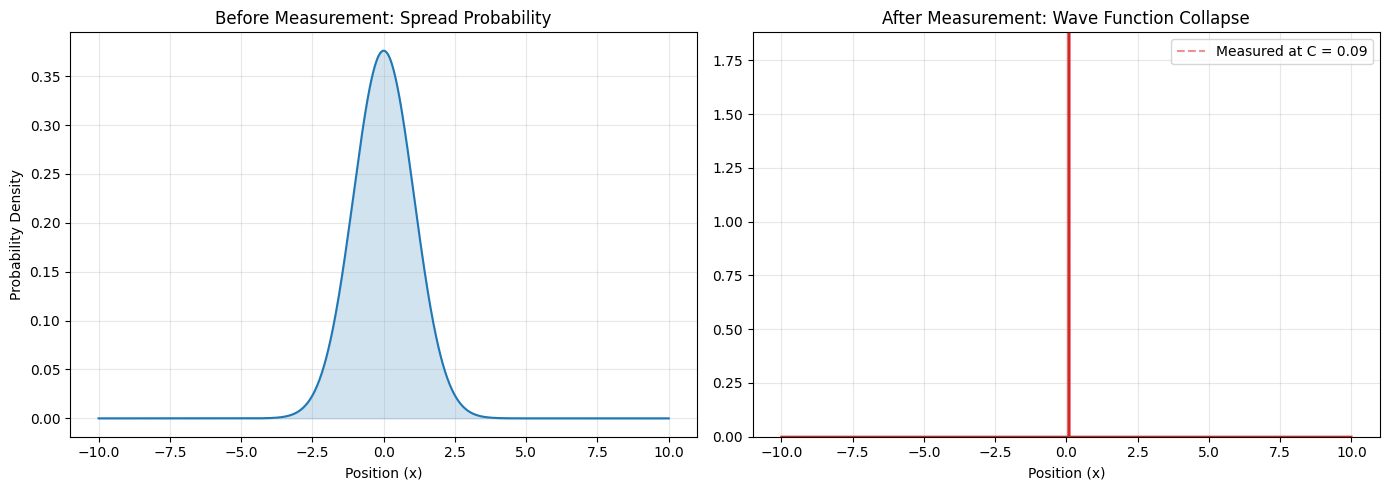

In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add the parent directory to the path so Jupyter can find the 'src' folder
sys.path.append(os.path.abspath('..'))

# Import your custom quantum mechanics library!
from src.wave_functions import gaussian_wave_packet, get_probability_density, measure_position

# 1. Setup the spatial grid
x_large = np.linspace(-10, 10, 1000)

# 2. Use your library functions
psi_initial = gaussian_wave_packet(x_large, sigma=1.5)
prob_density_initial = get_probability_density(psi_initial)

# Simulate the measurement
psi_collapsed, measured_position = measure_position(x_large, psi_initial)
prob_density_collapsed = get_probability_density(psi_collapsed)

# 3. Plotting (This remains the same)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before Measurement
ax1.plot(x_large, prob_density_initial, color='#1f77b4')
ax1.fill_between(x_large, prob_density_initial, alpha=0.2, color='#1f77b4')
ax1.set_title("Before Measurement: Spread Probability")
ax1.set_xlabel("Position (x)")
ax1.set_ylabel("Probability Density")
ax1.grid(alpha=0.3)

# After Measurement
ax2.plot(x_large, prob_density_collapsed, color='#d62728')
ax2.axvline(measured_position, color='#d62728', linestyle='--', alpha=0.5, 
            label=f'Measured at C = {measured_position:.2f}')
ax2.set_title("After Measurement: Wave Function Collapse")
ax2.set_xlabel("Position (x)")
ax2.set_ylim(0, max(prob_density_initial) * 5)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()